In [28]:
from langgraph.graph import StateGraph, START , END
from typing import TypedDict

In [29]:
class BatsmanState(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percentage: float

    summary: str

In [30]:
def calculate_sr(state: BatsmanState):
    return {
        "sr": (state["runs"] / state["balls"]) * 100
    }

In [31]:
def calculate_bpb(state: BatsmanState):
    return {
        "bpb": state["balls"] / (state["fours"] + state["sixes"])
    }

In [32]:
def calculate_boundary_percentage(state: BatsmanState):
    return {
        "boundary_percentage": (((state["fours"]*4) + (state["sixes"]*6)) / state["runs"]) * 100
    }

In [33]:
def summary_stats(state: BatsmanState):
    summary = f"""
Strike Rate: {state['sr']}
Balls per Boundary: {state['bpb']}
Boundary Percentage: {state['boundary_percentage']}
"""

    return {
        "summary": summary
    }

In [34]:
graph = StateGraph(BatsmanState)

# nodes
graph.add_node('calculate_sr', calculate_sr )
graph.add_node('calculate_bpb', calculate_bpb )
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage )
graph.add_node('summary_stats', summary_stats )

# edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percentage')

graph.add_edge('calculate_sr', 'summary_stats')
graph.add_edge('calculate_bpb', 'summary_stats')
graph.add_edge('calculate_boundary_percentage', 'summary_stats')

graph.add_edge('summary_stats', END)

# compile the graph
cricket_stats_workflow = graph.compile()

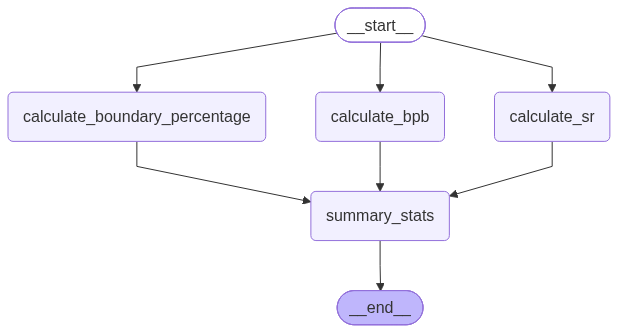

In [35]:
from IPython.display import Image
Image(cricket_stats_workflow.get_graph().draw_mermaid_png())

In [36]:
# execute/invoke the graph
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 5
}

final_state = cricket_stats_workflow.invoke(initial_state)

print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 5, 'sr': 200.0, 'bpb': 4.545454545454546, 'boundary_percentage': 54.0, 'summary': '\nStrike Rate: 200.0\nBalls per Boundary: 4.545454545454546\nBoundary Percentage: 54.0\n'}
